# 01 — Exploring Calgary's water main data

**Problem:** each year Calgary can replace only ~1% of its water mains (over a 5-year horizon).
Which pipes should it replace first so the most future breaks are avoided?

This notebook builds an understanding of the data before any modelling:

1. Look at the raw rows
2. Sort every column into ID / categorical / continuous / datetime / geometry
3. Continuous columns: percentiles, then distributions
4. Categorical columns: counts
5. Link each break to the pipe it happened on
6. What the prediction target looks like

**No peeking at the test period:** the final model is tested on breaks in 2021–2025, so any
target-related look in this notebook uses only breaks **before 2021**.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shapely.geometry import Point
from shapely.strtree import STRtree

from src.data import link_breaks_to_pipes, load_breaks, load_pipes

pd.set_option("display.max_columns", 30)
pipes, geoms = load_pipes()
breaks = load_breaks()
print(f"pipes: {pipes.shape}   breaks: {breaks.shape}")

pipes: (60740, 7)   breaks: (37538, 7)


# Part 1 — What do the rows look like?

### breaks — one row per recorded water main break

In [2]:
breaks[['BREAK_DATE', 'BREAK_TYPE', 'STATUS', 'point']].head()

,BREAK_DATE,BREAK_TYPE,STATUS,point
0,1978/04/01,C,ACTIVE,POINT (-114.0570152 50.9991217)
1,1982/09/01,AC,ACTIVE,POINT (-114.2013989 51.0867841)
2,1978/10/01,B,RETIRED,POINT (-114.0614874 51.0924081)
3,1978/08/01,E,ACTIVE,POINT (-114.0689266 51.0014316)
4,1990/02/01,A,RETIRED,POINT (-114.0753895 51.092555)


### pipes — one row per pipe segment in the ground today

In [3]:
pipes.head()

,year,globalid,status_ind,material,length,p_zone,diam
0,2003,493983f6-25ae-4a01-831b-6eb2d9731557,ACTIVE,PVC,2.4321,BROADCAST HILL,200
1,2001,e7994366-d91d-44eb-84a9-0f83b96ede7a,ACTIVE,PVC,49.5008,BROADCAST HILL,200
2,2003,1823b7ea-dbb8-4b08-b5f4-07fec8a0b180,ACTIVE,PVC,2.5093,BROADCAST HILL,200
3,2000,fd27ce5b-bcd1-4bc6-8f5e-af58a45da7b2,ACTIVE,PVC,11.0720,BROADCAST HILL,250
4,2003,b6712f69-25be-4916-9250-b7df862306d7,ACTIVE,PVC,148.2202,BROADCAST HILL,250


**Pattern:** two tables with **no shared ID**. A break has a date, a failure code, a status and a
location; a pipe has material, diameter (`diam`, mm), install `year`, `length` (m) and a pressure zone
(`p_zone`). The only link between them is location — handled in Part 5.

# Part 2 — What kind of column is each one?

In [4]:
def profile(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "null_%": (df.isna().mean() * 100).round(1),
        "example": df.iloc[0].astype(str).str[:30],
    })

print("=== breaks ==="); print(profile(breaks[["BREAK_DATE", "BREAK_TYPE", "STATUS", "point"]]).to_string())
print("\n=== pipes ==="); print(profile(pipes).to_string())

=== breaks ===
           dtype  n_unique  null_%                         example
BREAK_DATE   str      5865     0.0                      1978/04/01
BREAK_TYPE   str       157     0.0                               C
STATUS       str         2     0.0                          ACTIVE
point        str     37464     0.0  POINT (-114.0570152 50.9991217

=== pipes ===
              dtype  n_unique  null_%                         example
year          int64       113     0.0                            2003
globalid        str     60740     0.0  493983f6-25ae-4a01-831b-6eb2d9
status_ind      str         3     0.0                          ACTIVE
material        str        25     0.0                             PVC
length      float64     55665     0.0                          2.4321
p_zone          str        45     2.4                  BROADCAST HILL
diam          int64        33     0.0                             200


Reading the profile — storage type alone is misleading:

- `diam` is stored as a number but takes a few **standard sizes** (150, 200, 250 mm…) — closer to an
  ordered category than a free measurement.
- `year` is a number, but what matters physically is **age** at the time of prediction.
- `BREAK_TYPE` looks like free text but is a **code for how the pipe failed** (decoded in Part 4);
  combinations such as `AC` mean two failure modes at once.
- `globalid` is an identifier with no meaning to a model.

In [5]:
COLUMN_KIND = {
    "id": ["globalid"],
    "datetime": ["BREAK_DATE"],
    "categorical": ["BREAK_TYPE", "STATUS", "material", "p_zone", "status_ind"],
    "ordinal (standard sizes)": ["diam"],
    "continuous": ["length", "year"],
    "geometry": ["point", "pipe line (separate geometry list)"],
}
covered = {c for cols in COLUMN_KIND.values() for c in cols}
assert set(pipes.columns) <= covered and {"BREAK_DATE", "BREAK_TYPE", "STATUS", "point"} <= covered
pd.Series({k: ", ".join(v) for k, v in COLUMN_KIND.items()}, name="columns").to_frame()

,columns
id,globalid
datetime,BREAK_DATE
categorical,"BREAK_TYPE, STATUS, material, p_zone, status_ind"
ordinal (standard sizes),diam
continuous,"length, year"
geometry,"point, pipe line (separate geometry list)"


# Part 3 — Continuous columns

### 3.1 Percentiles first

In [6]:
PCT = [.01, .05, .25, .5, .75, .95, .99]
pipes[["length", "year", "diam"]].describe(percentiles=PCT).T.round(1)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
length,60740.0,89.2,113.7,0.0,0.7,1.7,11.8,58.8,119.9,283.1,491.6,3194.1
year,60740.0,1988.6,21.9,1900.0,1910.0,1953.0,1975.0,1992.0,2004.0,2020.0,2023.0,2033.0
diam,60740.0,246.5,158.5,0.0,50.0,150.0,150.0,200.0,300.0,400.0,1050.0,1950.0


**What stands out:**

- **Length is very skewed:** median ~59 m; 5% of segments are longer than ~280 m and 5% shorter than
  ~2 m.
- **Install years** run from 1900 to recent; half of today's segments were installed in 1992 or later.
- A few install years lie in the **future** (max 2033) and a few diameters are **0** — planned or
  mis-keyed records, to be filtered before modelling.

The exact values are in the table above; the next plots show the shapes.

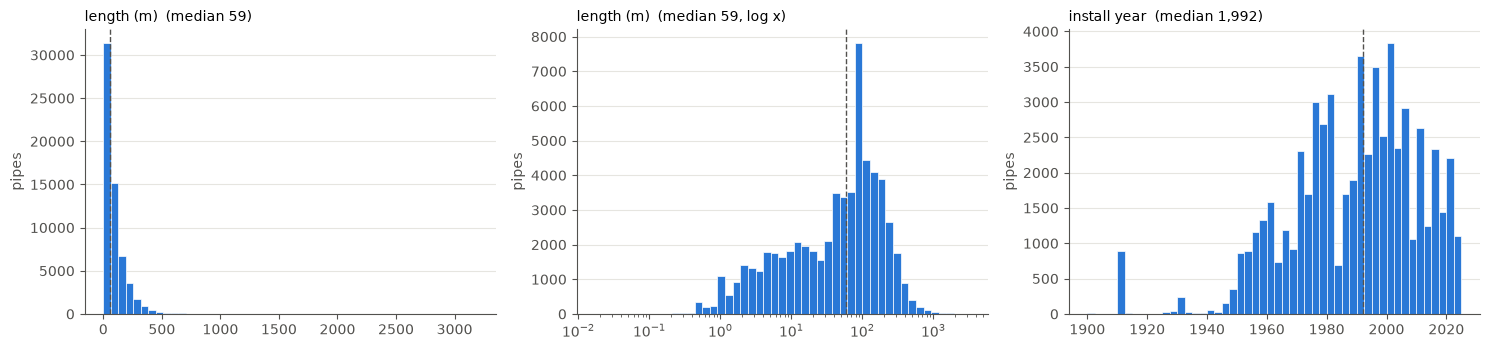

In [7]:
BLUE, ORANGE, INK = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e6e5e0", "axes.axisbelow": True,
})

def dist(ax, s, title, log=False):
    s = s.dropna()
    if log:
        s = s[s > 0]
        bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 50)
        ax.set_xscale("log")
    else:
        bins = 50
    ax.hist(s, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.axvline(s.median(), color=INK, linestyle="--", linewidth=1)
    ax.set_title(f"{title}  (median {s.median():,.0f}{', log x' if log else ''})", fontsize=10, loc="left")
    ax.set_ylabel("pipes")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
dist(axes[0], pipes.length, "length (m)")
dist(axes[1], pipes.length, "length (m)", log=True)
dist(axes[2], pipes.year[pipes.year <= 2026], "install year")
fig.tight_layout()

**Reading the plots** (dashed line = median):

- **Length** on a normal scale is one tall bar near zero; on a log scale it becomes a hump around
  50–150 m with a tail of tiny fragments. Length must be handled carefully: a long pipe breaks more
  just because there is more of it.
- **Install year** is not smooth: some periods added far more pipe than others (peaks in the histogram).

# Part 4 — Categorical columns

### 4.1 Pipe material — by count and by length

Total network: 5,419 km in 60,740 segments
PVC share of length: 53%
Cast iron (CI): 743 km (14%)


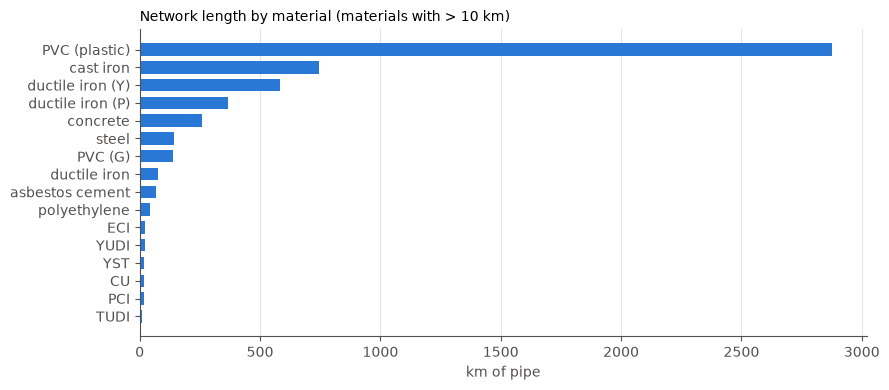

In [8]:
MATERIAL_NAMES = {"PVC": "PVC (plastic)", "CI": "cast iron", "YDI": "ductile iron (Y)", "PDI": "ductile iron (P)",
                  "CON": "concrete", "ST": "steel", "PVCG": "PVC (G)", "DI": "ductile iron", "AC": "asbestos cement",
                  "PE": "polyethylene"}
km = (pipes.groupby("material").length.sum() / 1000).sort_values()
km = km[km > 10]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([MATERIAL_NAMES.get(m, m) for m in km.index], km.values, color=BLUE, height=0.7)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("km of pipe"); ax.set_title("Network length by material (materials with > 10 km)", fontsize=10, loc="left")
fig.tight_layout()
total_km = pipes.length.sum() / 1000
print(f"Total network: {total_km:,.0f} km in {len(pipes):,} segments")
print(f"PVC share of length: {pipes.length[pipes.material == 'PVC'].sum() / 1000 / total_km:.0%}")
print(f"Cast iron (CI): {pipes.length[pipes.material == 'CI'].sum() / 1000:,.0f} km "
      f"({pipes.length[pipes.material == 'CI'].sum() / 1000 / total_km:.0%})")

### 4.2 Which material was laid when?

decade,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
group,,,,,,,,,,,,,
PVC,1,0,0,0,0,0,0,21,448,864,839,556,149
CI,0,98,7,20,58,372,188,0,0,0,0,0,0
YDI,0,0,0,0,0,0,0,411,161,7,4,1,0
PDI,0,0,0,0,0,0,41,326,0,0,0,0,0
CON,0,0,0,12,0,10,31,64,69,21,29,24,0
other,0,1,0,1,1,30,129,165,24,144,47,31,14


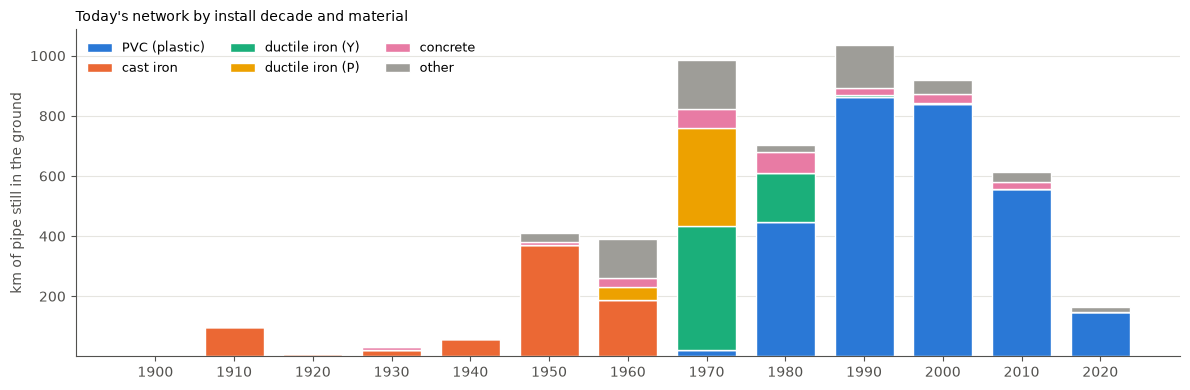

In [9]:
TOP = ["PVC", "CI", "YDI", "PDI", "CON"]
SLOT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#9e9d98"]   # fixed categorical order, grey = other
p2 = pipes[pipes.year.between(1900, 2026)].copy()
p2["decade"] = (p2.year // 10 * 10).astype(int)
p2["group"] = np.where(p2.material.isin(TOP), p2.material, "other")
stack = (p2.groupby(["decade", "group"]).length.sum() / 1000).unstack(fill_value=0)[TOP + ["other"]]

fig, ax = plt.subplots(figsize=(12, 4))
bottom = np.zeros(len(stack))
for col, color in zip(stack.columns, SLOT):
    ax.bar(stack.index.astype(str), stack[col], bottom=bottom, color=color, width=0.75,
           edgecolor="white", linewidth=1, label=MATERIAL_NAMES.get(col, col))
    bottom += stack[col].values
ax.set_ylabel("km of pipe still in the ground")
ax.set_title("Today's network by install decade and material", fontsize=10, loc="left")
ax.legend(frameon=False, ncol=3, fontsize=9)
fig.tight_layout()
(stack.round(0).astype(int).T)

**Finding:** PVC is the largest material by length; cast iron is the second largest (shares printed
above). The material names in the data are codes; readable labels are added for the plots.

### 4.3 How pipes fail — the break codes

Breaks with more than one failure mode: 31%


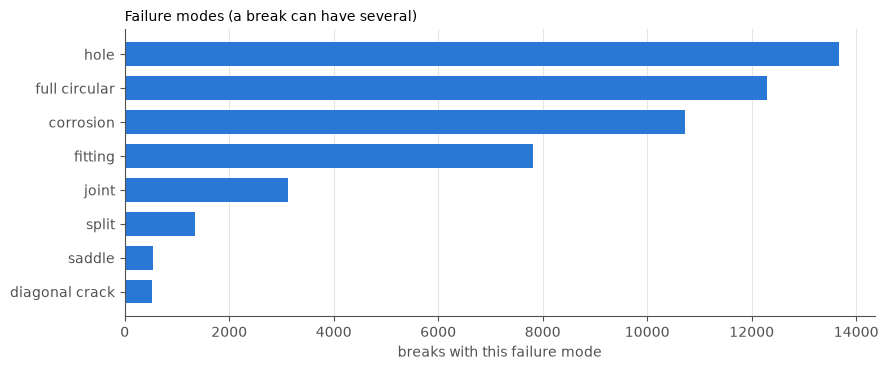

In [10]:
MODES = {"A": "full circular", "B": "split", "C": "corrosion", "D": "fitting",
         "E": "joint", "F": "diagonal crack", "G": "hole", "S": "saddle"}
letters = breaks.BREAK_TYPE.str.replace(r"\d", "", regex=True)
mode_counts = pd.Series({name: letters.str.contains(code).sum() for code, name in MODES.items()}).sort_values()
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(mode_counts.index, mode_counts.values, color=BLUE, height=0.7)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("breaks with this failure mode")
ax.set_title("Failure modes (a break can have several)", fontsize=10, loc="left")
fig.tight_layout()
print(f"Breaks with more than one failure mode: {(letters.str.len() > 1).mean():.0%}")

**Finding:** the code definitions come from the dataset's own metadata. Full circular cracks, holes and
corrosion are the most frequent modes, and about a third of breaks record more than one mode.

**Modelling decision (an assumption, not a finding):** the label counts **all** breaks, assuming that
replacing a segment renews the pipe, joints and fittings and so prevents every mode.

### 4.4 Break status, and breaks over time

STATUS
RETIRED    22255
ACTIVE     15283

Breaks dated on the 1st of a month: 79%


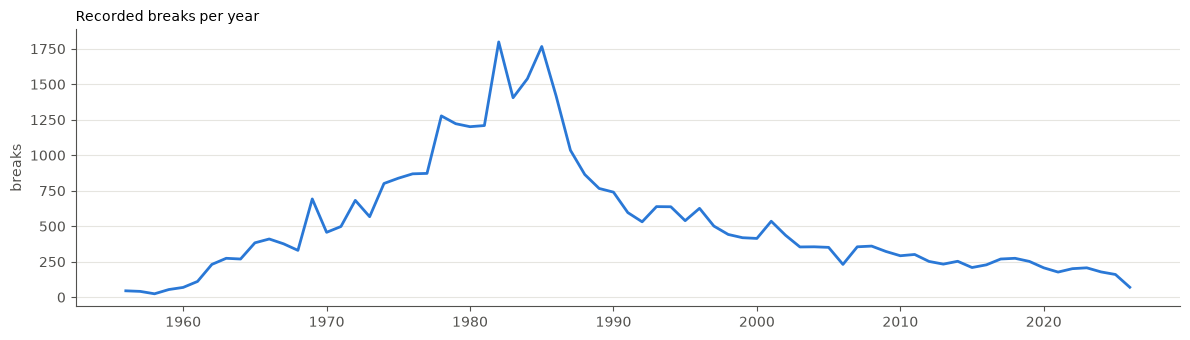

In [11]:
print(breaks.STATUS.value_counts().to_string())
per_year = breaks.groupby(breaks.break_date.dt.year).size()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(per_year.index, per_year.values, color=BLUE, linewidth=2)
ax.set_ylabel("breaks"); ax.set_title("Recorded breaks per year", fontsize=10, loc="left")
fig.tight_layout()
print(f"\nBreaks dated on the 1st of a month: {(breaks.break_date.dt.day == 1).mean():.0%}")

**Findings:**

- Recorded breaks **peaked in the 1980s** (~1,800 in a single year) and have fallen steadily since.
  A model trained on older years would learn a higher break rate than recent years show: **drift**,
  which matters later for calibration. (2026 is a partial year.)
- `STATUS` is ACTIVE or RETIRED; the metadata doesn't define it — Part 5 tests what it means.
- **Most breaks are dated the 1st of the month**, so dates are effectively month-precision. A 5-year
  prediction horizon makes that harmless.

### 4.5 Why were there so many breaks in the 1980s?

The break table alone can't say *why*, but three things in the data narrow it down: which breaks were on
pipes that were later replaced (STATUS), when the replacements went in, and which materials the
remaining breaks were on. This section uses the break-to-pipe link built in Part 5.

STATUS,ACTIVE,RETIRED,All
decade,,,
1950,61,103,164
1960,871,2274,3145
1970,1773,6310,8083
1980,3897,9104,13001
1990,2722,2947,5669
2000,2762,951,3713
2010,2083,480,2563
2020,1114,86,1200
All,15283,22255,37538


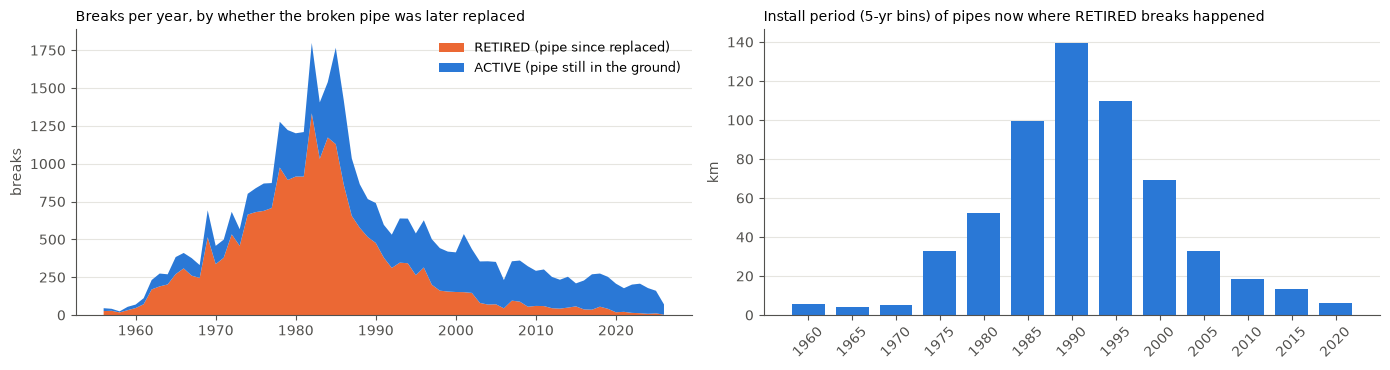

In [12]:
lk = link_breaks_to_pipes(breaks, geoms).join(pipes[["year", "material"]], on="pipe_idx")
lk["break_year"] = lk.break_date.dt.year
lk["decade"] = lk.break_year // 10 * 10

by_status = lk.groupby(["break_year", "STATUS"]).size().unstack(fill_value=0)
retired = lk[lk.STATUS == "RETIRED"].drop_duplicates("pipe_idx")
replaced_km = pipes.loc[retired.pipe_idx.astype(int)].pipe(lambda d: d.length.groupby(d.year // 5 * 5).sum() / 1000)
replaced_km = replaced_km.loc[1960:2025]

fig, (a, c) = plt.subplots(1, 2, figsize=(14, 3.8))
a.stackplot(by_status.index, by_status.RETIRED, by_status.ACTIVE, colors=[ORANGE, BLUE],
            labels=["RETIRED (pipe since replaced)", "ACTIVE (pipe still in the ground)"])
a.set_ylabel("breaks"); a.legend(frameon=False, fontsize=9, loc="upper right")
a.set_title("Breaks per year, by whether the broken pipe was later replaced", fontsize=10, loc="left")
c.bar(replaced_km.index.astype(str), replaced_km.values, color=BLUE, width=0.75)
c.set_ylabel("km"); c.tick_params(axis="x", rotation=45)
c.set_title("Install period (5-yr bins) of pipes now where RETIRED breaks happened", fontsize=10, loc="left")
fig.tight_layout()
pd.crosstab(lk.decade, lk.STATUS, margins=True)

**Findings:**

- **Most 1980s breaks were on pipes that no longer exist:** 9,104 of the 13,001 breaks in the 1980s are
  RETIRED.
- **The pipes in those spots were mostly installed 1985–1999** (right plot), i.e. the broken pipes were
  replaced shortly after the peak, and yearly breaks fell over the same period (left plot).
- So the data shows a **peak of breaks on pipes that were then replaced**, followed by a decline. It does
  not show *why* those pipes broke more (no weather, soil or pressure data here).

**Were the replaced pipes mainly cast iron?** The material of a replaced pipe is not recorded — the pipe
is gone. Two indirect clues:

1. **How they broke.** On pipes we *can* identify, cast iron fails mostly by full circular cracks or at
   joints (codes A/E); ductile iron fails by holes or at fittings (G/D). Compare RETIRED breaks with both,
   decade by decade (same decade, so the coding era is the same).
2. **What surrounds them.** The material of other pipes within 100 m that were already in the ground when
   the break happened.

In [13]:
lk_codes = lk.BREAK_TYPE.str.replace(r"\d", "", regex=True)
lk["circular_or_joint"] = lk_codes.str.contains("[AE]")
lk["group"] = np.select(
    [lk.STATUS == "RETIRED", lk.material == "CI", lk.material.isin(["PDI", "YDI", "DI"])],
    ["RETIRED (material unknown)", "ACTIVE cast iron", "ACTIVE ductile iron"], "ACTIVE other")
sig = (lk[lk.decade.between(1960, 1990) & (lk.group != "ACTIVE other")]
       .groupby(["decade", "group"]).circular_or_joint.mean().unstack())
# If RETIRED breaks are a mix of cast iron (share x) and ductile iron (1 - x), their circular/joint share
# is x * CI_share + (1 - x) * DI_share -> solve for x.
sig["implied cast-iron share of RETIRED"] = ((sig["RETIRED (material unknown)"] - sig["ACTIVE ductile iron"])
                                             / (sig["ACTIVE cast iron"] - sig["ACTIVE ductile iron"])).clip(0, 1)
sig.round(2)

group,ACTIVE cast iron,ACTIVE ductile iron,RETIRED (material unknown),implied cast-iron share of RETIRED
decade,,,,
1960,0.84,0.75,0.87,1.00
1970,0.76,0.16,0.53,0.61
1980,0.58,0.04,0.25,0.40
1990,0.65,0.02,0.36,0.54


In [14]:
old = lk[(lk.STATUS == "RETIRED") & lk.decade.between(1960, 1990)].reset_index(drop=True)
near_rows, near_pipes = STRtree(geoms).query([Point(x, y).buffer(100) for x, y in zip(old.x, old.y)], predicate="intersects")
nb = pd.DataFrame({"row": near_rows, "pipe_idx": near_pipes}).join(pipes[["year", "material", "length"]], on="pipe_idx")
nb = nb[(nb.year < old.break_year.values[nb.row]) & (nb.pipe_idx != old.pipe_idx.values[nb.row])]
nb["mat"] = nb.material.where(nb.material.isin(["CI", "PDI", "YDI", "PVC"]), "other")
mix = nb.groupby(["row", "mat"]).length.sum().unstack(fill_value=0)
mix = mix.div(mix.sum(axis=1), axis=0)
print(f"RETIRED breaks with an already-existing neighbour within 100 m: {len(mix):,} of {len(old):,}")
mix.groupby(old.decade.values[mix.index]).mean().round(2).rename_axis("decade")

RETIRED breaks with an already-existing neighbour within 100 m: 16,733 of 20,635


mat,CI,PDI,PVC,YDI,other
decade,,,,,
1960,0.80,0.01,0.00,0.00,0.19
1970,0.54,0.13,0.00,0.03,0.30
1980,0.28,0.27,0.08,0.12,0.25
1990,0.36,0.10,0.24,0.09,0.21


**Findings** (indirect evidence, not a measurement):

- **1960s:** replaced pipes broke like cast iron (87% circular/joint vs 84% for cast iron) and their
  neighbours were ~80% cast iron → very likely **cast iron**. (The implied share of 1.00 is unreliable:
  only 4 ductile-iron breaks exist in the 1960s to compare with, so the neighbour clue carries this decade.)
- **1980s:** replaced pipes broke mostly by **holes and fittings**, the ductile-iron pattern; the
  failure-mode mix implies only roughly 40% cast iron, and their neighbours were a mix of cast iron and
  both ductile iron types.
- So the **1980s peak was not mainly cast iron**: the evidence points to a large share of
  **ductile iron**, which section 4.2 shows was laid in the 1960s–70s — i.e. those pipes failed and were
  replaced within roughly 10–25 years of being installed.
- Assumption behind clue 1: replaced pipes of a material failed like the surviving pipes of that material
  in the same decade.

material,CI,PDI,YDI,PVC,other
decade,,,,,
1950,59,0,0,1,1
1960,809,0,1,2,59
1970,1313,133,29,16,282
1980,1757,901,609,70,560
1990,1096,978,136,35,477
2000,1296,668,339,69,390
2010,1207,355,263,44,214
2020,598,188,191,32,105


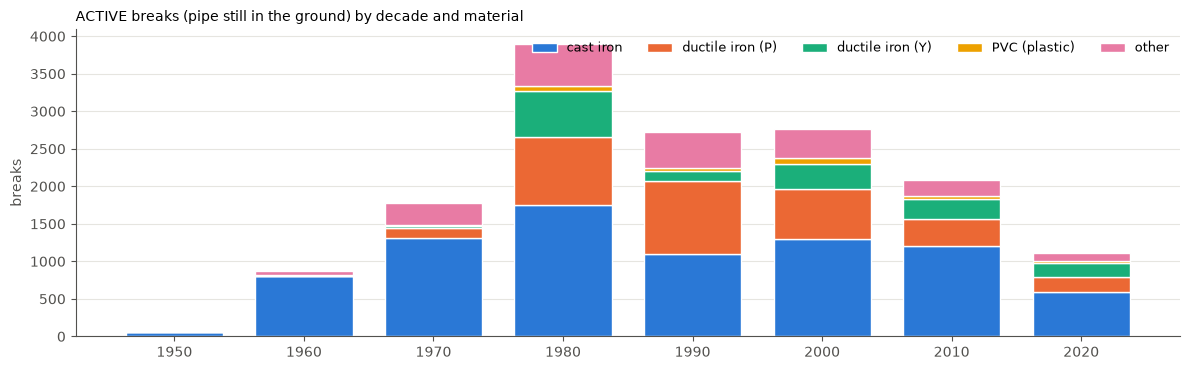

In [15]:
active_mat = lk[lk.STATUS == "ACTIVE"]
groups = active_mat.material.where(active_mat.material.isin(["CI", "PDI", "YDI", "PVC"]), "other")
mat_dec = pd.crosstab(active_mat.decade, groups)[["CI", "PDI", "YDI", "PVC", "other"]]
fig, ax = plt.subplots(figsize=(12, 3.8))
bottom = np.zeros(len(mat_dec))
for col, color in zip(mat_dec.columns, SLOT):
    ax.bar(mat_dec.index.astype(str), mat_dec[col], bottom=bottom, color=color, width=0.75,
           edgecolor="white", linewidth=1, label=MATERIAL_NAMES.get(col, col))
    bottom += mat_dec[col].values
ax.set_ylabel("breaks"); ax.legend(frameon=False, ncol=5, fontsize=9)
ax.set_title("ACTIVE breaks (pipe still in the ground) by decade and material", fontsize=10, loc="left")
fig.tight_layout()
mat_dec

**Finding:** among breaks on pipes still in the ground, the 1980s are dominated by **cast iron** and the two
**ductile iron** types — which section 4.2 shows were laid in the 1960s–70s, so they were 10–20 years old
when their breaks rose. PVC accounts for very few breaks in any decade.

In [16]:
codes = lk.BREAK_TYPE.str.replace(r"\d", "", regex=True)
mode_share = pd.DataFrame({name: codes.str.contains(code) for code, name in MODES.items()}).groupby(lk.decade).mean()
first_of_month = (lk.break_date.dt.day == 1).groupby(lk.decade).mean().rename("dated on the 1st")
pd.concat([mode_share[["corrosion", "hole", "full circular", "fitting", "joint"]], first_of_month], axis=1).round(2)

,corrosion,hole,full circular,fitting,joint,dated on the 1st
decade,,,,,,
1950,0.01,0.02,0.50,0.02,0.18,0.98
1960,0.09,0.03,0.66,0.02,0.20,0.99
1970,0.31,0.32,0.41,0.10,0.15,1.00
1980,0.36,0.41,0.21,0.33,0.06,0.99
1990,0.05,0.48,0.29,0.22,0.04,0.89
2000,0.12,0.44,0.29,0.23,0.03,0.03
2010,0.67,0.37,0.38,0.15,0.03,0.04
2020,0.67,0.37,0.35,0.07,0.03,0.03


**Finding — a warning about how breaks were recorded:**

- Until the 1990s almost every break is dated the 1st of the month; from the 2000s exact days are
  recorded. The recording system changed around 2000.
- Failure-mode shares jump in ways that look like **coding changes, not physics** — e.g. corrosion is
  recorded on ~36% of 1980s breaks, ~5% in the 1990s and ~67% in the 2010s.
- **Consequence for modelling:** a feature like "number of past corrosion breaks" means different things
  in different eras, so break-type features must be treated with caution.

### 4.6 Failure mode by pipe material and decade

Counts for breaks on pipes **still in the ground** (ACTIVE) — the only breaks whose material is known.
A break with two failure modes is counted under both, so rows can sum to more than the number of breaks.

decade                  1950   1960   1970   1980   1990   2000   2010   2020
material                                                                     
CI       corrosion       0.0   21.0  243.0  651.0   49.0  141.0  839.0  462.0
         fitting         1.0   27.0   76.0  390.0  103.0  149.0  122.0   28.0
         full circular  25.0  394.0  558.0  667.0  598.0  691.0  754.0  369.0
         hole            0.0    6.0  121.0  234.0  261.0  343.0  260.0  149.0
         joint          16.0  291.0  441.0  362.0  113.0   57.0   37.0   15.0
         split          16.0   85.0   93.0   74.0   48.0   71.0   56.0   23.0
PDI      corrosion       NaN    NaN   23.0  356.0   62.0   91.0  253.0  142.0
         fitting         NaN    NaN   79.0  501.0  482.0  269.0   65.0    5.0
         full circular   NaN    NaN    5.0   15.0    7.0   12.0   11.0    6.0
         hole            NaN    NaN   39.0  400.0  562.0  410.0  244.0  130.0
         joint           NaN    NaN   10.0   11.0    5.0    4.0    2.0    4.0
         split           NaN    NaN    2.0    5.0    2.0    4.0    0.0    0.0
PVC      corrosion       0.0    0.0    5.0   26.0    1.0   11.0   20.0   11.0
         fitting         0.0    0.0    3.0   37.0   10.0   17.0   13.0   11.0
         full circular   1.0    1.0    7.0    8.0    4.0    1.0    5.0    3.0
         hole            0.0    0.0    1.0   17.0   12.0   21.0    7.0    6.0
         joint           0.0    0.0    4.0    5.0    3.0    6.0    3.0    2.0
         split           0.0    1.0    0.0    5.0    6.0   19.0   10.0    8.0
YDI      corrosion       NaN    0.0    3.0  150.0   11.0   59.0  139.0   63.0
         fitting         NaN    0.0   10.0  454.0   82.0  203.0   98.0   31.0
         full circular   NaN    1.0    6.0   14.0    7.0    6.0    9.0    4.0
         hole            NaN    0.0    9.0  130.0   46.0  121.0  101.0   70.0
         joint           NaN    0.0    2.0   14.0    4.0    5.0    8.0    7.0
         split           NaN    0.0    0.0    0.0    1.0    0.0    1.0    0.0

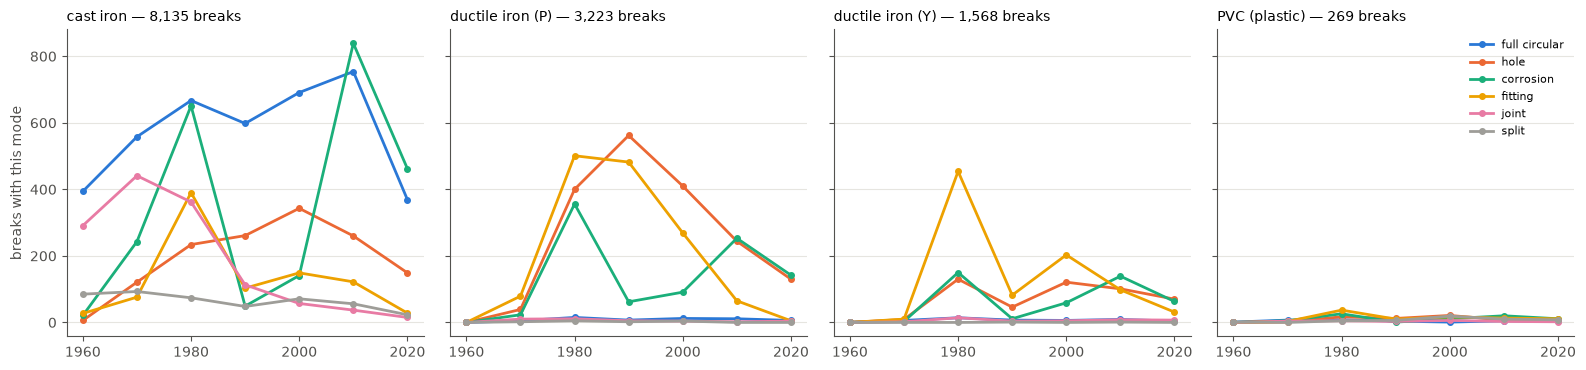

In [17]:
MAT4 = ["CI", "PDI", "YDI", "PVC"]
MODE_ORDER = ["full circular", "hole", "corrosion", "fitting", "joint", "split"]
act = lk[(lk.STATUS == "ACTIVE") & lk.material.isin(MAT4)].copy()
act_codes = act.BREAK_TYPE.str.replace(r"\d", "", regex=True)
for code, name in MODES.items():
    act[name] = act_codes.str.contains(code)
counts = act.groupby(["material", "decade"])[MODE_ORDER].sum().astype(int)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, mat in zip(axes, MAT4):
    t = counts.loc[mat].reindex(range(1960, 2030, 10), fill_value=0)
    for name, color in zip(MODE_ORDER, SLOT):
        ax.plot(t.index, t[name], color=color, linewidth=2, marker="o", markersize=4, label=name)
    ax.set_title(f"{MATERIAL_NAMES[mat]} — {int(act.material.eq(mat).sum()):,} breaks", fontsize=10, loc="left")
    ax.set_xticks(range(1960, 2030, 20))
axes[0].set_ylabel("breaks with this mode")
axes[-1].legend(frameon=False, fontsize=8)
fig.tight_layout()
counts.unstack("material").T.swaplevel().sort_index()

**Findings** (from the table above; mode coding changes over time, see 4.5):

- **Materials fail in different ways.** Cast iron fails mostly by **full circular cracks** (roughly
  560–750 per decade from the 1970s to the 2010s) and, in older decades, at **joints**. Both ductile iron
  types almost never crack circularly (≤15 per decade); they fail by **holes** and at **fittings**.
- **Cast-iron joint failures fall steadily:** 441 in the 1970s → 37 in the 2010s.
- **Ductile iron (PDI) peaked in the 1980s–90s:** ~500 fitting failures per decade and 562 holes in the
  1990s — the same period that drives the 1980s peak in 4.5.
- **PVC barely appears** in any mode (at most ~37 in a cell).
- The **2020s are a partial decade** (2020 – mid-2026), so every line drops there partly for that reason.
- **Modelling implication:** what a past break *means* depends on the material, so material should be
  combined with break history rather than used alone.

# Part 5 — Linking each break to its pipe

Breaks carry no pipe ID, so each break is attached to the **nearest pipe**. Two checks decide whether
that is trustworthy: how far is the nearest pipe, and does the matched pipe make sense in time?

In [18]:
linked = link_breaks_to_pipes(breaks, geoms)
linked = linked.join(pipes[["year", "material", "length"]], on="pipe_idx")
print("Distance from break to nearest pipe (m):")
print(linked.link_dist_m.describe(percentiles=[.5, .9, .99]).round(2)[["50%", "90%", "99%", "max"]].to_string())

linked["pipe_newer_than_break"] = linked.year > linked.break_date.dt.year
linked.groupby("STATUS").pipe_newer_than_break.mean().rename("share matched to a pipe installed after the break").round(3)

Distance from break to nearest pipe (m):
50%     0.77
90%     1.10
99%     1.25
max    59.11


STATUS
ACTIVE     0.004
RETIRED    0.919
Name: share matched to a pipe installed after the break, dtype: float64

**Findings:**

- Breaks sit **about 1 m from a pipe** (99% within 1.3 m) — they were recorded on the pipe line itself,
  so the nearest-pipe match is reliable. A handful of outliers sit up to ~60 m away.
- For **RETIRED** breaks, the matched pipe was almost always installed **after** the break: the pipe
  that broke has since been **replaced**, and today's inventory only has its successor.
- For **ACTIVE** breaks that almost never happens.

So `STATUS` = whether the broken pipe is still in the ground (an inference, not documented).
**Decision:** use ACTIVE breaks only — they belong to pipes we can still describe and rank.
**Limitation (survivorship):** pipes already replaced are missing from the inventory and from training;
22,255 breaks (the RETIRED ones) cannot be attached to a pipe we can describe.

In [19]:
active = linked[(linked.STATUS == "ACTIVE") & ~linked.pipe_newer_than_break].copy()
print(f"Usable breaks: {len(active):,} of {len(linked):,}, on {active.pipe_idx.nunique():,} pipes")

Usable breaks: 15,216 of 37,538, on 6,587 pipes


# Part 6 — What does the prediction target look like?

The target: **for each pipe in the ground on 1 January of a planning year, how many times will it break
in the next 5 years?** To avoid looking at the test period, this section uses the planning date
**1 Jan 2011** and breaks in **2011–2015**.

In [20]:
CUT, H = 2011, 5
cohort = pipes[(pipes.year < CUT) & (pipes.length > 0)].copy()
cohort["km"] = cohort.length / 1000
past = active[active.break_date.dt.year < CUT].groupby("pipe_idx").size()
future = active[active.break_date.dt.year.between(CUT, CUT + H - 1)].groupby("pipe_idx").size()
cohort["past_breaks"] = cohort.index.map(past).fillna(0)
cohort["target"] = cohort.index.map(future).fillna(0)

print("Breaks per pipe in 2011-2015:")
print(cohort.target.value_counts().sort_index().to_string())
print(f"\nPipes that broke at least once: {(cohort.target > 0).mean():.1%}")

Breaks per pipe in 2011-2015:
target
0.0    49836
1.0      769
2.0       96
3.0        9
4.0        2

Pipes that broke at least once: 1.7%


**Finding:** about 98% of pipes have **zero** breaks in five years. The target is a rare count — so
accuracy is useless ("never breaks" scores ~99%), and the metric must reflect the city's budget:
**recall at 1% of network length** (of all breaks, the share on the riskiest 1% of km).

### 6.1 Break rate by material and by install decade

,km,rate
material,,
CON,245.3,0.1
PVC,2245.2,0.1
PVCG,140.2,0.3
ST,115.6,1.2
YDI,583.2,3.9
AC,66.4,4.8
PDI,367.2,9.5
DI,74.4,9.9
CI,743.0,15.9


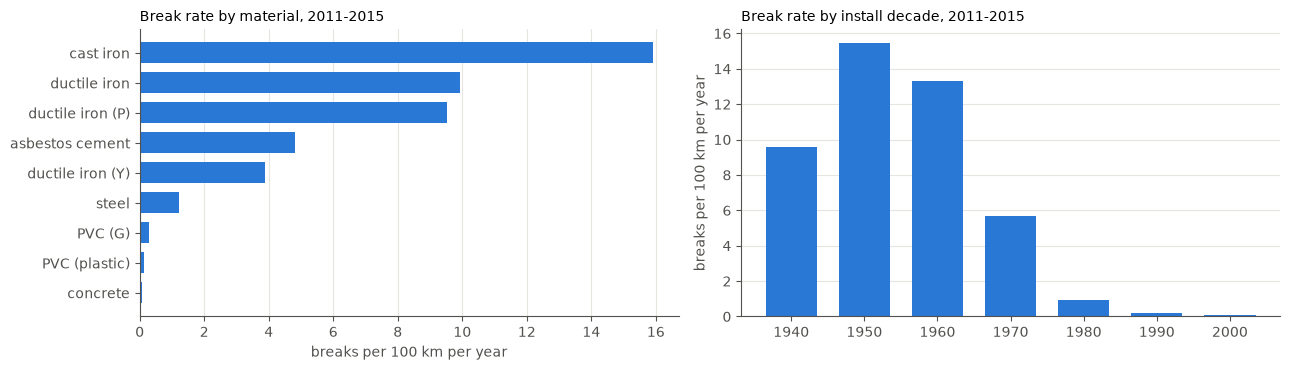

In [21]:
def rate_per_100km_yr(df):
    return df.target.sum() / (df.km.sum() * H) * 100

by_mat = cohort.groupby("material").apply(lambda d: pd.Series({"km": d.km.sum(), "rate": rate_per_100km_yr(d)}))
by_mat = by_mat[by_mat.km > 50].sort_values("rate")
cohort["decade"] = (cohort.year // 10 * 10).clip(1940, 2000)
by_dec = cohort.groupby("decade").apply(rate_per_100km_yr)

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 3.8))
a.barh([MATERIAL_NAMES.get(m, m) for m in by_mat.index], by_mat.rate, color=BLUE, height=0.7)
a.grid(axis="x"); a.grid(axis="y", visible=False)
a.set_xlabel("breaks per 100 km per year"); a.set_title("Break rate by material, 2011-2015", fontsize=10, loc="left")
b.bar(by_dec.index.astype(int).astype(str), by_dec.values, color=BLUE, width=0.7)
b.set_ylabel("breaks per 100 km per year"); b.set_title("Break rate by install decade, 2011-2015", fontsize=10, loc="left")
fig.tight_layout()
by_mat.round(1)

**Finding:** material and install decade separate risk sharply — cast iron breaks at ~16 per 100 km
per year against ~0.1 for PVC, and pipes installed before the 1970s break far more often than those
installed after (rates in the table and plot above).

### 6.2 Do pipes that broke before break again?

In [22]:
broke_before = cohort.past_breaks > 0
print(f"Pipes with a past break: {broke_before.mean():.1%} of pipes, {cohort.km[broke_before].sum():,.0f} km")
print(f"Share of 2011-2015 breaks on those pipes: {cohort.target[broke_before].sum() / cohort.target.sum():.0%}")
print(f"Rate with past break:    {rate_per_100km_yr(cohort[broke_before]):.1f} per 100 km-yr")
print(f"Rate without past break: {rate_per_100km_yr(cohort[~broke_before]):.1f} per 100 km-yr")

h = cohort[broke_before].copy()
h["length_band"] = pd.cut(h.length, [0, 20, 50, 100, 200, 1e6], labels=["<=20 m", "20-50", "50-100", "100-200", ">200 m"])
h.groupby("length_band", observed=True).apply(lambda d: pd.Series({"pipes": len(d), "breaks_per_km_5yr": d.target.sum() / d.km.sum()})).round(2)

Pipes with a past break: 11.3% of pipes, 865 km
Share of 2011-2015 breaks on those pipes: 66%
Rate with past break:    15.3 per 100 km-yr
Rate without past break: 1.7 per 100 km-yr


,pipes,breaks_per_km_5yr
length_band,,
<=20 m,269.0,1.07
20-50,577.0,0.77
50-100,1485.0,0.90
100-200,1985.0,0.89
>200 m,1403.0,0.64


**Findings:**

- Pipes that broke before (~11% of pipes, ~16% of length) carry **about two-thirds of the next breaks**
  and break ~9x more often per km — repeat offenders.
  "Past breaks per km" is therefore a strong simple rule, and the baseline any model must beat.
- Among repeat offenders, **short segments break more per km** (~1.7x the longest band here).
  Ranking must work **per km**, because the budget is spent in km.
- The rest of the network — pipes with no break yet — is where a history rule has nothing to say.

### 6.3 Do breaks on nearby pipes signal risk for a pipe with no history?

In [23]:
recent = active[active.break_date.dt.year.between(CUT - 10, CUT - 1)]
tree = STRtree([Point(x, y) for x, y in zip(recent.x, recent.y)])
pipe_rows, break_rows = tree.query([geoms[i].buffer(150) for i in cohort.index], predicate="intersects")
pairs = pd.DataFrame({"pipe_idx": cohort.index.values[pipe_rows], "break_pipe": recent.pipe_idx.values[break_rows]})
pairs = pairs[pairs.pipe_idx != pairs.break_pipe]
cohort["nearby_breaks"] = cohort.index.map(pairs.groupby("pipe_idx").size()).fillna(0)

clean = cohort[~broke_before].copy()
clean["nearby"] = pd.cut(clean.nearby_breaks, [-1, 0, 1, 3, 1e9], labels=["0", "1", "2-3", "4+"])
clean.groupby("nearby", observed=True).apply(lambda d: pd.Series({"km": d.km.sum(), "rate_per_100km_yr": rate_per_100km_yr(d)})).round(2)

,km,rate_per_100km_yr
nearby,,
0,2747.14,0.79
1,480.31,3.00
2-3,433.96,4.79
4+,203.55,5.11


**Finding:** among pipes that **never broke**, those with breaks within 150 m in the previous 10 years
break ~4-6x more often in 2011–2015 than those with none (table above). A rule based only on a pipe's
own history cannot use this; it is a candidate model feature.

# Summary

1. Two tables, no shared ID; breaks link to pipes by location (~1 m apart) — reliable.
2. `STATUS = RETIRED` marks breaks on pipes since replaced → use ACTIVE breaks; survivorship is a
   stated limitation.
3. Length is heavily skewed; ranking and the budget must be **per km**.
4. Breaks peaked in the 1980s — mostly on pipes that were then replaced (replacements installed 1985–1999),
   which by indirect evidence were largely ductile iron rather than cast iron — and fell
   since → **drift**; models trained on older years will over-predict today unless recalibrated.
5. The way breaks were recorded changed around 2000 (exact dates, different failure-mode coding) →
   break-type features are era-dependent.
6. Target: ~98% of pipes have zero breaks in 5 years → rare counts; metric = recall at 1% of length.
7. Signals: material and era (strong), a pipe's own break history (strongest, but only ~11% of pipes
   have one), short repeat-offender segments, and breaks on nearby pipes (for pipes with no history).